In [15]:
import math

print("=" * 50)
print(" OPTIMUM HORIZONTAL TAIL SIZING")
print("=" * 50)

# -----------------------------
# Inputs
# -----------------------------
c = 0.7531 # Mean aerodynamic chord, m
Sw = 11.25  # Wing area, m^2
VH = 0.6   # Horizontal tail volume coefficient
Kc = 1.0   # Correction factor for tail efficiency
b_w = 15.0  # Wing span, m
L = 0.45*b_w  # Aircraft length, m
l_over_L = 0.65  # Tail arm to aircraft length ratio

# -----------------------------
# Calculations
# -----------------------------

# Optimum tail arm

l= l_over_L * L
Df = (4 * c * Sw * VH) / (math.pi * l**2)

# Horizontal tail area
Sh = (c * Sw * VH) / l

# -----------------------------
# Results
# -----------------------------
print("\n" + "=" * 50)
print("RESULTS")
print("=" * 50)

print(f"Optimum Tail Arm (l)      = {l:.3f} m")
print(f"Horizontal Tail Area (Sh) = {Sh:.3f} m²")
print(f"Maximum fuselage diameter (Df) = {Df:.3f} m")
print(f"Aircraft length (L) = {L:.3f} m")

print("=" * 50)




 OPTIMUM HORIZONTAL TAIL SIZING

RESULTS
Optimum Tail Arm (l)      = 4.388 m
Horizontal Tail Area (Sh) = 1.159 m²
Maximum fuselage diameter (Df) = 0.336 m
Aircraft length (L) = 6.750 m


In [16]:
# ============================================================
# 1. WING 
# ============================================================

e = 0.8 # Oswald efficiency factor, e

AR_w = 20 # wing aspect ratio, AR_w

CL_w = 0.824 # wing lift coefficient

CL0_w = 0.422635 # wing zero-lift coefficient, CL0_w

alpha_w = 3.45 # wing angle of attack, alpha_w (deg)

CLalpha_w = 0.0966  # wing lift-curve slope, 1/deg  5.5341

sweep_deg = 0.0 # wing sweep angle, Lambda (deg)    

Cm_af = -0.14  # airfoil pitching-moment coefficient

alpha_twist_deg = 0 # wing twist angle, alpha_t (deg)

alpha_f = 0 # fuselage angle of attack, alpha_f (deg) glide angle

i_w = alpha_w - alpha_f # wing incidence angle, i_w (deg)

# ============================================================
# 2. TAIL 
# ============================================================


eta_h = 0.85 # tail efficiency, eta_h

AR_h = 4.0 # tail aspect ratio, AR_h

Clalpha_h = 0.1148   # tail AIRFOIL lift-curve slope, Clalpha_h (1/deg)

#CLalpha_h = 5.960 # tail LIFT-curve slope, CLalpha_h (1/rad)

alpha_L0_h_deg = 0.0 # tail zero-lift angle


# ============================================================
# 3. CG AND AERODYNAMIC-CENTRE INPUTS
# ============================================================

h = 0.35 # nondimensional CG position, h

h0 = 0.25 # nondimensional aerodynamic-centre position, h0



# ============================================================
# INPUT CHECKS
# ============================================================

if AR_w <= 0:
    raise ValueError("Wing aspect ratio must be greater than zero.")

if AR_h <= 0:
    raise ValueError("Tail aspect ratio must be greater than zero.")

if VH <= 0:
    raise ValueError("Tail volume coefficient must be greater than zero.")

if not 0 < eta_h <= 1:
    raise ValueError("Tail efficiency must be between 0 and 1.")

if eta_h < 0.85 or eta_h > 0.95:
    print(
        "\nWarning: conventional-tail efficiency is normally "
        "approximately 0.85 to 0.95."
    )

# ============================================================
# 4. ANGLE CONVERSIONS
# ============================================================

# alpha_w_rad = math.radians(alpha_w_deg)
# alpha_f_rad = math.radians(alpha_f_deg)
# i_w_rad = math.radians(i_w_deg)
# alpha_L0_h_rad = math.radians(alpha_L0_h_deg)
# sweep_rad = math.radians(sweep_deg)


In [17]:
import math


# ============================================================
# 5. WING-FUSELAGE PITCHING MOMENT
# ============================================================

cos_sweep = math.cos(sweep_deg)

Cm0_wf = (Cm_af * (AR_w * cos_sweep**2 / (AR_w + 2.0 * cos_sweep))+ 0.01 * alpha_twist_deg )

# ============================================================
# 9. REQUIRED TAIL LIFT COEFFICIENT FROM TRIM
# ============================================================

CL_h = (Cm0_wf + CL_w * (h - h0)) / (eta_h * VH)

# ============================================================
# 7. FINITE-WING HORIZONTAL-TAIL LIFT-CURVE SLOPE AND REQUIRED TAIL ANGLE OF ATTACK
# ============================================================

CLalpha_h = ( Clalpha_h / (1.0+ (Clalpha_h / (math.pi * AR_h*e))))

alpha_h = ( CL_h / CLalpha_h )

# ============================================================
# DOWNWASH
# ============================================================

epsilon_0 = ((2.0 * CL0_w) / (math.pi * AR_w))*(180/math.pi)  # Downwash at zero AoA, epsilon_0 (deg)

downwash_slope = ( 2.0 * CLalpha_w * 57.3 / (math.pi * AR_w))

epsilon = ( epsilon_0 + (downwash_slope * alpha_w))



# print(f"downwash_slope = {downwash_slope: .4f}")
# print(f"epsilon_0_deg = {epsilon_0_deg: .4f} deg")
# print(f"epsilon_deg = {epsilon_deg: .4f} deg")
# print(f"epsilon_rad = {epsilon_rad: .4f} rad")
# print(f"epsilon_0_rad = {epsilon_0_rad: .4f} rad")
# print(f"alpha_w_rad = {alpha_w_rad: .4f} rad")

# ============================================================
# 11. REQUIRED TAIL ANGLE AND INCIDENCE FOR TRIM
# ============================================================

i_h = ( alpha_h - alpha_f + epsilon)


# ============================================================
# STATIC LONGITUDINAL STABILITY DERIVATIVE
# ============================================================

Cm_alpha = (
    CLalpha_w * (h - h0)
    - CLalpha_h
    * eta_h
    * (Sh / Sw)
    * ((l / c) - h)
    * (1 - downwash_slope)
)


# ============================================================
# 12. RESULTS
# ============================================================

print("\n" + "=" * 72)
print(" CALCULATION RESULTS")
print("=" * 72)



print("\n1. Wing–fuselage pitching moment")
print("-" * 72)
print(f"Cm0,wf                         = {Cm0_wf: .5f}")
print(f"Wing incidence, i_w            = {i_w: .4f} deg")

print("\n2. Downwash")
print("-" * 72)
print(f"Downwash at zero AoA, epsilon_0 = {epsilon_0: .4f} deg")
print(f"Downwash slope, dε/dalpha       = {downwash_slope: .4f}")
print(f"Total downwash angle, epsilon   = {epsilon: .4f} deg")

print("\n3. Horizontal-tail aerodynamic parameters")
print("-" * 72)
print(f"tail CL_h                       = {CL_h: .5f}")
print(f"Tail airfoil slope, Clalpha_h   = {Clalpha_h: .4f} 1/rad")
print(f"Finite-tail slope, CLalpha_h    = {CLalpha_h: .4f} 1/rad")
print(f"Tail angle of attack, alpha_h   = {alpha_h: .4f} deg")
print(f"tail incidence, i_h             = {i_h: .4f} deg")


print("\n5. Tail setting required for exact trim")
print("-" * 72)
print(f"tail incidence, i_h    = {i_h: .4f} deg")

print("\n" + "=" * 72)
print("STATIC LONGITUDINAL STABILITY")
print("=" * 72)

print(f"Cm_alpha = {Cm_alpha:.6f} 1/rad")

if Cm_alpha < 0:
    print("Aircraft is statically longitudinally STABLE.")
elif Cm_alpha > 0:
    print("Aircraft is statically longitudinally UNSTABLE.")
else:
    print("Aircraft is neutrally stable.")

print("\n" + "=" * 72)



 CALCULATION RESULTS

1. Wing–fuselage pitching moment
------------------------------------------------------------------------
Cm0,wf                         = -0.12727
Wing incidence, i_w            =  3.4500 deg

2. Downwash
------------------------------------------------------------------------
Downwash at zero AoA, epsilon_0 =  0.7708 deg
Downwash slope, dε/dalpha       =  0.1762
Total downwash angle, epsilon   =  1.3787 deg

3. Horizontal-tail aerodynamic parameters
------------------------------------------------------------------------
tail CL_h                       = -0.08799
Tail airfoil slope, Clalpha_h   =  0.1148 1/rad
Finite-tail slope, CLalpha_h    =  0.1135 1/rad
Tail angle of attack, alpha_h   = -0.7752 deg
tail incidence, i_h             =  0.6035 deg

5. Tail setting required for exact trim
------------------------------------------------------------------------
tail incidence, i_h    =  0.6035 deg

STATIC LONGITUDINAL STABILITY
Cm_alpha = -0.035163 1/rad
Aircraft

In [18]:
#Neutral point calculation

hn = 0.25 + (eta_h * VH * (CLalpha_h / CLalpha_w) * (1 - downwash_slope))

print(f"Neutral point location, hn = {hn:.4f} (nondimensional)")
print(f"Static margin, SM = {hn - h:.4f} (nondimensional)")

Neutral point location, hn = 0.7437 (nondimensional)
Static margin, SM = 0.3937 (nondimensional)


In [19]:
print(CLalpha_w)
print(i_w,i_h)
print(epsilon_0)
print(downwash_slope)
print(CLalpha_h)
print(VH)


0.0966
3.45 0.6034717722063823
0.7707938120762297
0.17619025158067947
0.11350385777323425
0.6


CL0_w = 0.4226
CL0_w_the = 0.4907
Trim angle of attack: 3.50 deg


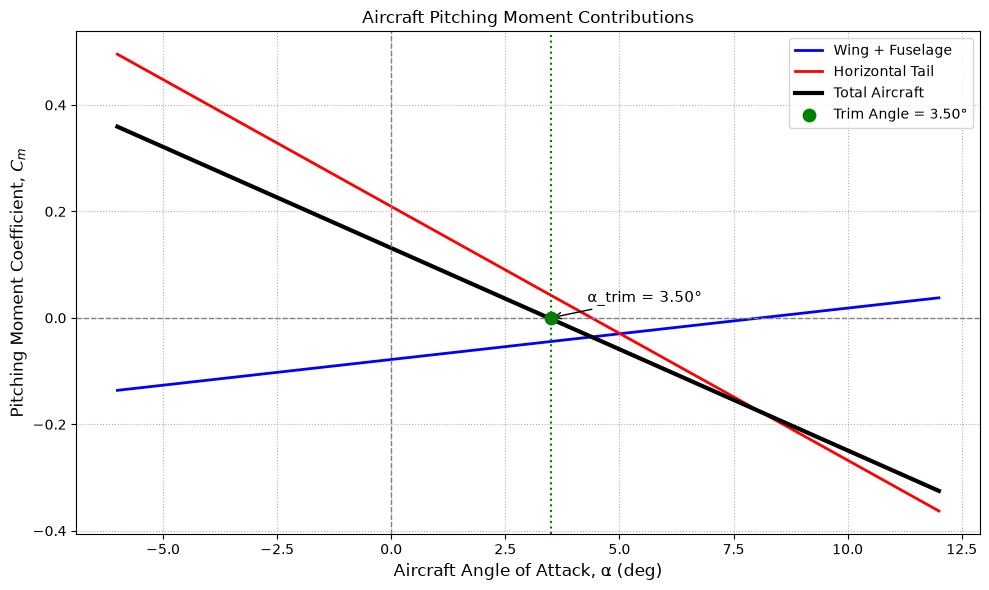

In [20]:
import numpy as np
import matplotlib.pyplot as plt

alpha = np.linspace(-6, 12, 200)
# alpha_rad = np.radians(alpha_deg)

CL0_w_the = CL_w - CLalpha_w * alpha_w
print(f"CL0_w = {CL0_w:.4f}")
print(f"CL0_w_the = {CL0_w_the:.4f}")

#ep_0 = (2.0 * CL_w) / (math.pi * AR_w*e)

#----------------------------------------------------------------------------------------------------------------------------

Cm_wing = Cm0_wf + (CL0_w_the + CLalpha_w * alpha) * (h-h0)  # Aircraft wing-fuselage pitching moment coefficient

Cm_tail = -1*eta_h * VH * CLalpha_h * (alpha*(1-downwash_slope) - epsilon_0 - i_w + i_h)  # Aircraft horizontal tail pitching moment coefficient

Cm_aircraft = Cm_wing + Cm_tail # Aircraft total pitching moment coefficient

#----------------------------------------------------------------------------------------------------------------------------

# Find where Cm changes sign
idx = np.where(np.diff(np.sign(Cm_aircraft)))[0]

if len(idx) > 0:
    i = idx[0]

    alpha_trim = np.interp(
        0,
        [Cm_aircraft[i], Cm_aircraft[i+1]],
        [alpha[i], alpha[i+1]]
    )
else:
    alpha_trim = None

print(f"Trim angle of attack: {alpha_trim:.2f} deg" if alpha_trim is not None else "No trim angle found.")

plt.figure(figsize=(10,6))

# Wing-Fuselage
plt.plot(alpha,
         Cm_wing,
         color='blue',
         linewidth=2,
         label='Wing + Fuselage')

# Horizontal Tail
plt.plot(alpha,
         Cm_tail,
         color='red',
         linewidth=2,
         label='Horizontal Tail')

# Total Aircraft
plt.plot(alpha,
         Cm_aircraft,
         color='black',
         linewidth=3,
         label='Total Aircraft')

if alpha_trim is not None:

    plt.scatter(alpha_trim,
                0,
                color='green',
                s=80,
                zorder=5,
                label=f'Trim Angle = {alpha_trim:.2f}°')

    plt.axvline(alpha_trim,
                color='green',
                linestyle=':',
                linewidth=1.5)

    plt.annotate(
        f'α_trim = {alpha_trim:.2f}°',
        xy=(alpha_trim, 0),
        xytext=(alpha_trim + 0.8, 0.03),
        arrowprops=dict(arrowstyle='->'),
        fontsize=11
    )

# Reference lines
plt.axhline(0,
            color='gray',
            linestyle='--',
            linewidth=1)

plt.axvline(0,
            color='gray',
            linestyle='--',
            linewidth=1)

# Design operating point
# Cm_design = Cm0_wf + CL_w*(h-h0) - eta_h*VH*CL_h

# plt.scatter(alpha_w_deg,
#             Cm_design,
#             color='green',
#             s=70,
#             zorder=5,
#             label='Design Point')

# Labels
plt.xlabel('Aircraft Angle of Attack, α (deg)', fontsize=12)
plt.ylabel('Pitching Moment Coefficient, $C_m$', fontsize=12)

plt.title('Aircraft Pitching Moment Contributions')

plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()

plt.show()




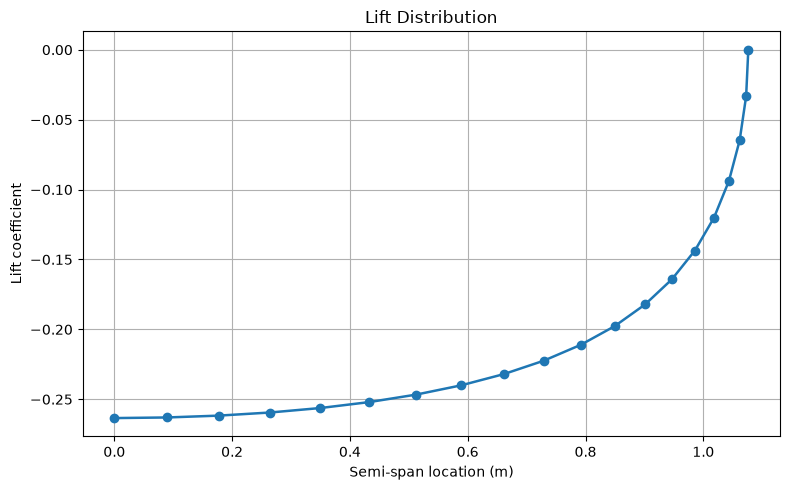

Tail arm (l)              =  4.38750 m
Aircraft length (L)        =  6.75000 m
AR of tail                 =  4.0000
Tail Span (b)              =  2.15278 m
Mean Aerodynamic Chord     =  0.53819 m
Root Chord                 =  0.53819 m
Tail area (S)              =  1.15862 m²
--------------------------------------------------
Tail incidence, i_h             =  0.6035 deg
Tail angle of attack, alpha_h   = -0.7752 deg
tail required CL_h                = -0.08799
--------------------------------------------------
--------------------------------------------------
Tail actual Lift Coefficient      = -0.22460
Actual tail incidence             = -1.7200 deg  (changed by user)
Actual tail angle of attack       = -3.0987 deg
--------------------------------------------------
Wing incidence, i_w               =  3.4500 deg
0 -1.72 1.3786501800295738


In [21]:
import numpy as np

# ============================================================
# INPUTS
# ============================================================

N = 19                       # (number of segments-1)
S = Sh                      # m^2
AR = AR_h                   # Aspect ratio
lam = 1.0                   # Taper ratio
alpha_twist = 0.00000      # Twist angle (deg)
a_2d = Clalpha_h * 57.3            # Lift curve slope (1/rad)
alpha_0 = 0.0         # Zero-lift angle of attack (deg)

# ============================================================
i_h_actual = -1.72  # Actual tail incidence (deg)
# ============================================================

alpha_h_actual = alpha_f + i_h_actual - epsilon
a_h = alpha_h_actual               # Tail angle of attack (deg)

# ============================================================
# GEOMETRY
# ============================================================

b = np.sqrt(AR * S)                                  # Tail span

MAC = S / b                                          # Mean Aerodynamic Chord

Croot = (1.5 * (1 + lam) * MAC) / (1 + lam + lam**2) # Root chord

theta = np.arange(np.pi/(2*N), np.pi/2 + np.pi/(2*N), np.pi/(2*N))

alpha = np.linspace(
    a_h + alpha_twist,
    a_h,
    N
)

z = (b/2) * np.cos(theta)

c = Croot * (1 - (1 - lam) * np.cos(theta))

# ============================================================
# LIFTING LINE
# ============================================================

mu = c * a_2d / (4 * b)

LHS = mu * (alpha - alpha_0) / 57.3

# ============================================================
# SOLVE N EQUATIONS
# ============================================================

B = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        B[i, j] = (
            np.sin((2*(j+1)-1) * theta[i])
            *
            (
                1
                +
                (
                    mu[i]
                    *
                    (2*(j+1)-1)
                )
                /
                np.sin(theta[i])
            )
        )

A = np.linalg.solve(B, LHS)

# ============================================================
# SUMMATIONS
# ============================================================

sum1 = np.zeros(N)
sum2 = np.zeros(N)

for i in range(N):
    sum1[i] = 0
    sum2[i] = 0

    for j in range(N):

        sum1[i] = (
            sum1[i]
            +
            (2*(j+1)-1)
            *
            A[j]
            *
            np.sin((2*(j+1)-1) * theta[i])
        )

        sum2[i] = (
            sum2[i]
            +
            A[j]
            *
            np.sin((2*(j+1)-1) * theta[i])
        )

# ============================================================
# TAIL LIFT COEFFICIENT
# ============================================================

CL_tail = np.pi * AR * A[0]

# ====================== PLOT ======================

# Local section lift coefficient
CL = 4 * b * sum2 / c

# Add zero lift coefficient at the wing tip
CL1 = np.concatenate(([0.0], CL))

# Add the wing-tip location to the semi-span coordinates
y_s = np.concatenate(([b / 2], z))


plt.figure(figsize=(8, 5))

plt.plot(
    y_s,
    CL1,
    "-o",
    linewidth=1.8,
    markersize=6
)

plt.grid(True)
plt.title("Lift Distribution")
plt.xlabel("Semi-span location (m)")
plt.ylabel("Lift coefficient")
plt.tight_layout()
plt.show()


# ============================================================
# RESULTS
# ============================================================

print (f"Tail arm (l)              = {l: .5f} m")
print(f"Aircraft length (L)        = {L: .5f} m")
print(f"AR of tail                 = {AR: .4f}")
print(f"Tail Span (b)              = {b: .5f} m")
print(f"Mean Aerodynamic Chord     = {MAC: .5f} m")
print(f"Root Chord                 = {Croot: .5f} m")
print(f"Tail area (S)              = {S: .5f} m²")
print("-" * 50)
print(f"Tail incidence, i_h             = {i_h: .4f} deg")
print(f"Tail angle of attack, alpha_h   = {alpha_h: .4f} deg")
print(f"tail required CL_h                = {CL_h: .5f}")
print("-" * 50)

print("-" * 50)
print(f"Tail actual Lift Coefficient      = {CL_tail: .5f}")
print(f"Actual tail incidence             = {i_h_actual: .4f} deg  (changed by user)")
print(f"Actual tail angle of attack       = {alpha_h_actual: .4f} deg")
print("-" * 50)
print(f"Wing incidence, i_w               = {i_w: .4f} deg")

print(alpha_f, i_h_actual, epsilon)


